Saved main NPZ to: C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\CavitySpec_versus_flux_20260814_1043_to_20260814_1052_Q.npz


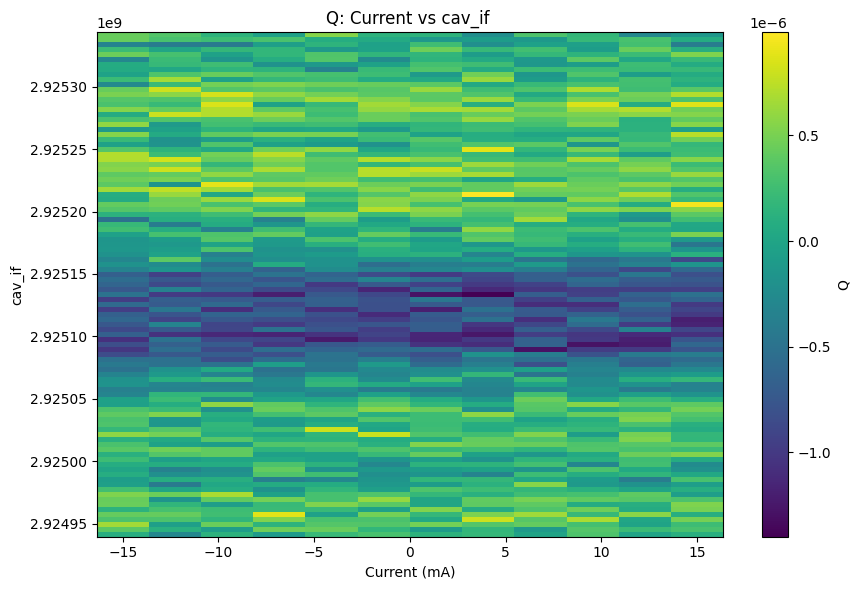

[2.92509751e+09 2.92510151e+09 2.92510151e+09 2.92513351e+09
 2.92509751e+09 2.92513751e+09 2.92513351e+09 2.92513351e+09
 2.92508951e+09 2.92509351e+09 2.92509351e+09 2.92511351e+09]


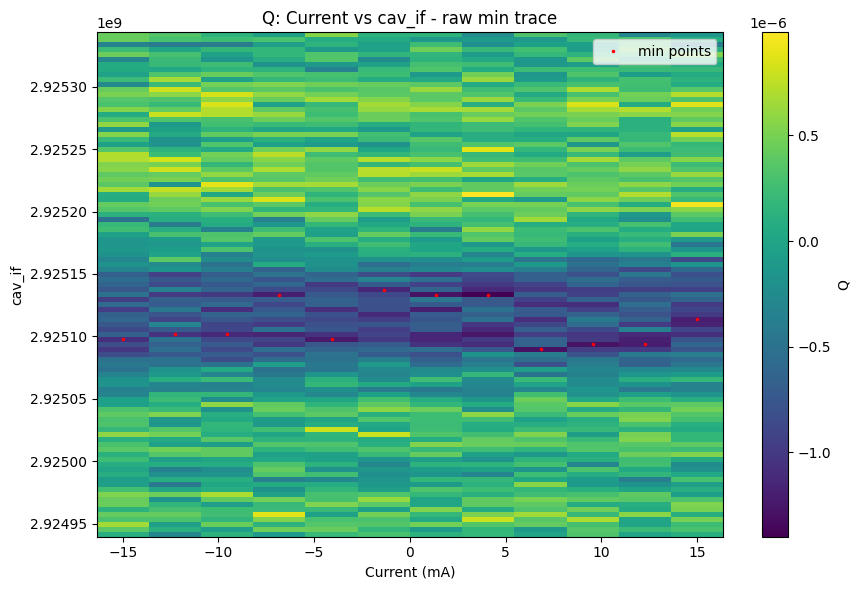

In [9]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# USER SETTINGS
# ==========================================================
build_npz_from_hdf5 = True
load_npz_for_analysis = True
# current_A_print =np.linspace(start=0e-3, stop=1e-3, num=11)
current_A_print2 =  np.linspace(start=-15e-3, stop=15e-3, num=12)#np.linspace(start=-6e-3, stop=6e-3, num=121) #np.linspace(start=-5e-3, stop=5e-3, num=41)
lo =  2.9e9 + 50e6 + 25.2e6-94e3+9.51e3+52e3/2 #2.897e9+50e6#6.61e9 + 50e6  # Hz

batches = [
    # {
    #     "date": "2026-08-08",
    #     "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-09",
    #     "time": ((11, 58), (12, 1)),
    #     "current": current_A_print,
    #     "lo": lo,
    # },
    {
        "date": "2026-08-14",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-25",
        "time": ((10, 43), (10, 52)),
        "current": current_A_print2,
        "lo": lo,
    },
    #     {
    #     "date": "2026-08-10",
    #     "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-10",
    #     "time": ((0, 0), (2, 50)),
    #     "current": current_A_print2[89:121],
    #     "lo": lo,
    # },
]


file_key = "CavitySpec_versus_flux"
plot_data = "Q"          # "I", "Q", or "MAG"
y_key = None             # None -> auto-choose sweep axis
subtract_mean = True
x_label, y_label = "Current", "cav_if"
show_individual_plots = False
plot_current_in_mA = True
output_folder = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data"
os.makedirs(output_folder, exist_ok=True)

# Generate names dynamically
st_d, end_d = batches[0]["date"].replace("-", ""), batches[-1]["date"].replace("-", "")
st_h, st_m = batches[0]["time"][0]
end_h, end_m = batches[-1]["time"][1]
save_npz_name = f"{file_key}_{st_d}_{st_h:02d}{st_m:02d}_to_{end_d}_{end_h:02d}{end_m:02d}_{plot_data}.npz"
npz_path = os.path.join(output_folder, save_npz_name)

# Trace & Outlier Settings
find_mode = "min"        # "min" or "max"
current_min_mA, current_max_mA = -15, -8
remove_outliers = True
jump_threshold = 0.005   # 5 MHz if in GHz
save_min_trace = True

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def extract_time(filename):
    try:
        parts = os.path.basename(filename).split("-")
        return (int(parts[0]), int(parts[1]))
    except Exception:
        return (-1, -1)

def get_filtered_files(folder, start_time, end_time, file_key):
    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        return []
    files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".hdf5") and file_key in f]
    return sorted([f for f in files if start_time <= extract_time(f) <= end_time])

def load_one_hdf5(filename, y_key=None, subtract_mean=True):
    with h5py.File(filename, "r") as f:
        key = y_key or next(k for k in f.keys() if k not in {"I", "Q", "Magnitude"})
        y_vals = np.array(f[key][()])
        
        # Flatten array averages instantly
        I_val = np.mean(f["I"][()], axis=0) if f["I"].ndim > 1 else np.array(f["I"][()])
        Q_val = np.mean(f["Q"][()], axis=0) if f["Q"].ndim > 1 else np.array(f["Q"][()])
        mag_val = np.mean(f["Magnitude"][()], axis=0) if "Magnitude" in f.keys() else np.sqrt(I_val**2 + Q_val**2)

        if subtract_mean:
            I_val -= np.mean(I_val)
            Q_val -= np.mean(Q_val)
            mag_val -= np.mean(mag_val)
            
    return key, y_vals, I_val, Q_val, mag_val

def base_mesh_plot(x, y, z, title_suffix=""):
    """Consolidated 2D Mesh plotting template to remove duplicate code block."""
    plt.figure(figsize=(9, 6))
    x_plot = x * 1e3 if plot_current_in_mA else x
    plt.pcolormesh(x_plot, y, z.T, shading="auto", cmap="viridis")
    plt.xlabel(f"{x_label} ({'mA' if plot_current_in_mA else 'A'})")
    plt.ylabel(y_label)
    plt.title(f"{plot_data}: {x_label} vs {y_label} {title_suffix}")
    plt.colorbar(label=plot_data)
    plt.tight_layout()

# ==========================================================
# PROCESSING & ANALYSIS
# ==========================================================

if build_npz_from_hdf5:
    grouped_files, x_values, file_dates, file_times = [], [], [], []
    
    for b in batches:
        files = get_filtered_files(b["folder"], b["time"][0], b["time"][1], file_key)
        n = min(len(files), len(b["current"]))
        
        grouped_files.extend(files[:n])
        x_values.extend(b["current"][:n])
        file_dates.extend([b["date"]] * n)
        file_times.extend([extract_time(f) for f in files[:n]])

    if not grouped_files:
        raise ValueError("No matching HDF5 files found.")

    I_2d, Q_2d, MAG_2d, sweep_axis = [], [], [], []
    for i, fname in enumerate(grouped_files):
        key, y_vals, I_v, Q_v, M_v = load_one_hdf5(fname, y_key, subtract_mean)
        sweep_axis.append(y_vals)
        I_2d.append(I_v)
        Q_2d.append(Q_v)
        MAG_2d.append(M_v)

    y_values = sweep_axis[0]
    
    np.savez_compressed(
        npz_path, x_values=x_values, current=x_values, current_mA=np.array(x_values)*1e3,
        y_values=y_values, cav_if=y_values, sweep_axis=sweep_axis, I=I_2d, Q=Q_2d, MAG=MAG_2d,
        x_label=x_label, y_label=y_label, y_key=key, filenames=grouped_files, 
        file_dates=file_dates, file_times=file_times, batch_dates=[b["date"] for b in batches],
        batch_start_times=[b["time"][0] for b in batches], batch_end_times=[b["time"][1] for b in batches],
        batch_folders=[b["folder"] for b in batches], file_key=file_key, subtract_mean=subtract_mean, plot_data_saved=plot_data
    )
    print(f"Saved main NPZ to: {npz_path}")

if load_npz_for_analysis:
    data = np.load(npz_path, allow_pickle=True)
    x_values = data["current"]
    y_values = data["cav_if"]+lo if "cav_if" in data.keys() else data["y_values"]
    data_2d = data[plot_data]

    # Step 3: Raw 2D Mesh Plot
    base_mesh_plot(x_values, y_values, data_2d)
    plt.show()

    # Step 4 & 5: Find Min/Max Trace & Plot Overlay
    idx = np.argmin(data_2d, axis=1) if find_mode == "min" else np.argmax(data_2d, axis=1)
    trace_y, trace_val = y_values[idx], data_2d[np.arange(data_2d.shape[0]), idx]
    print(y_values[idx])

    base_mesh_plot(x_values, y_values, data_2d, f"- raw {find_mode} trace")
    plt.plot(x_values * 1e3 if plot_current_in_mA else x_values, trace_y, "r.", markersize=3, label=f"{find_mode} points")
    plt.legend()
    plt.show()



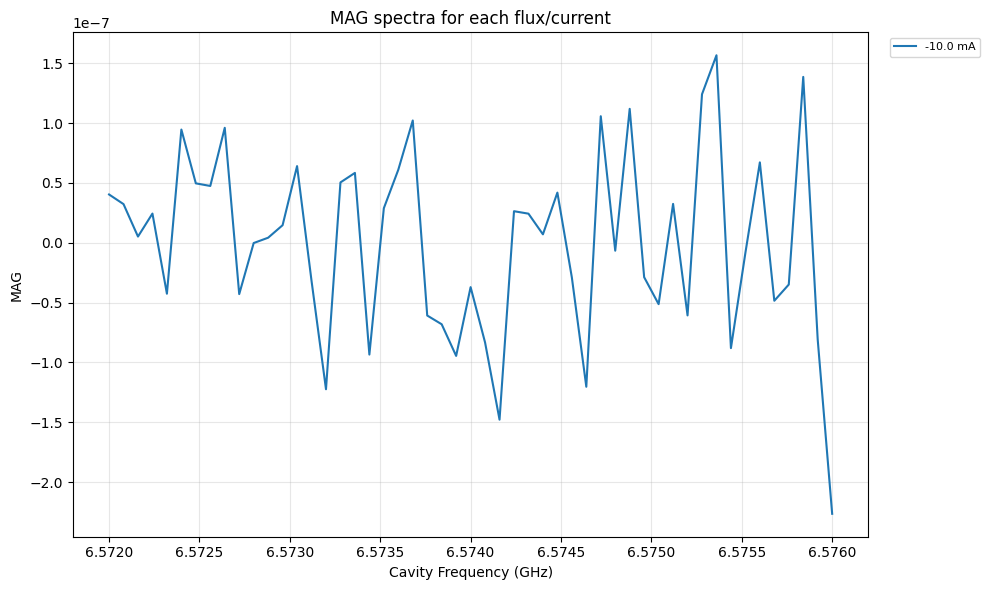

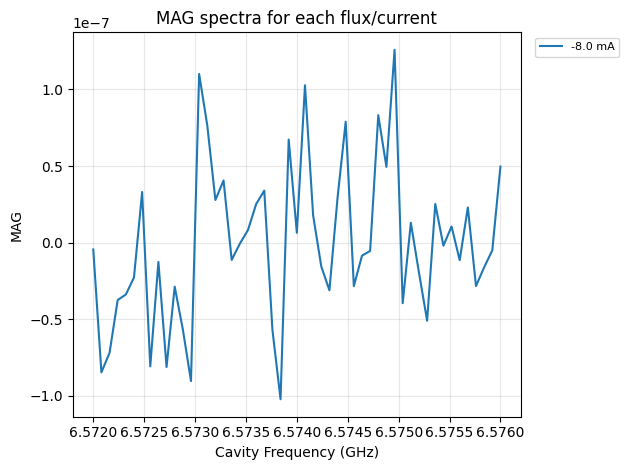

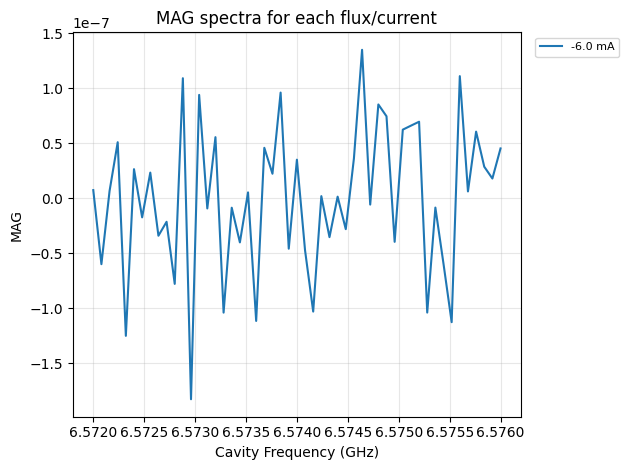

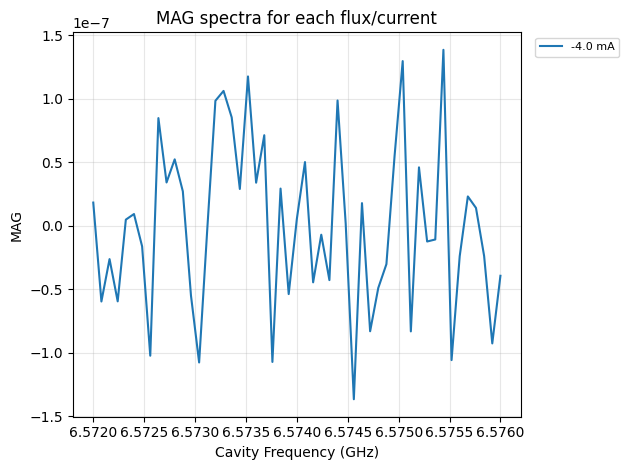

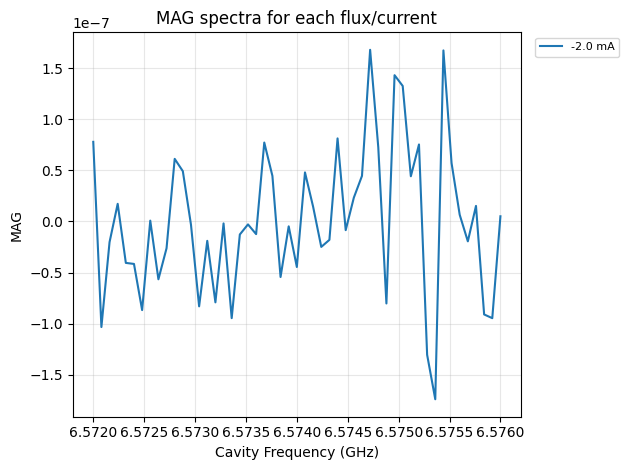

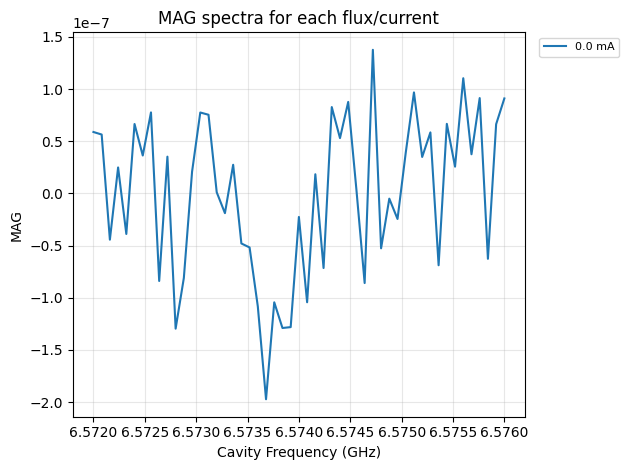

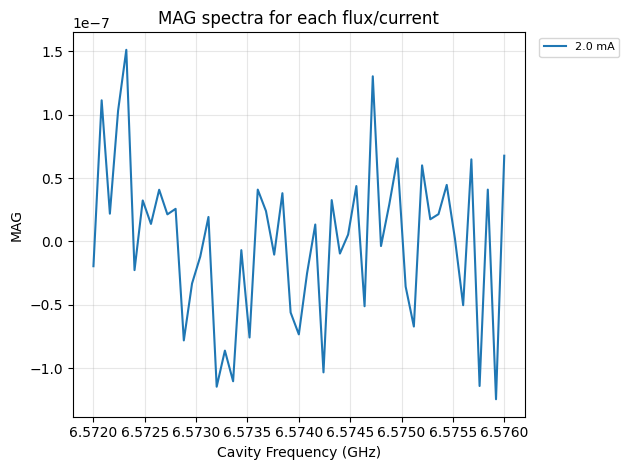

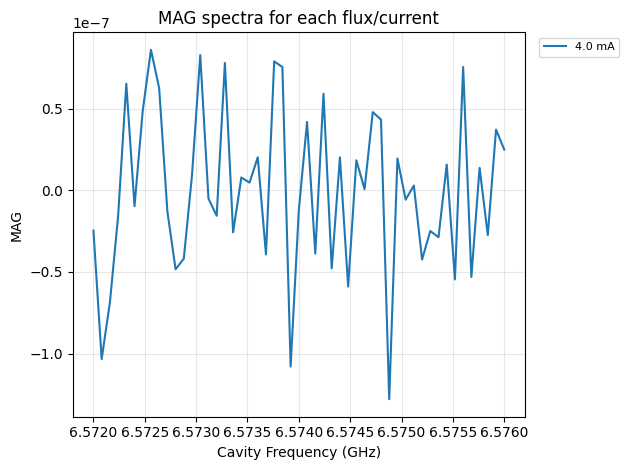

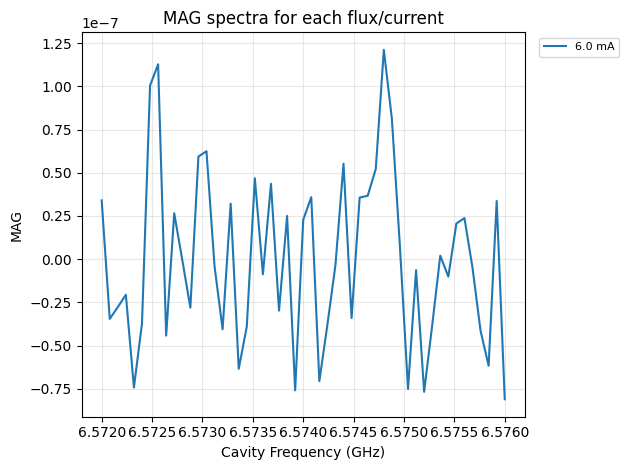

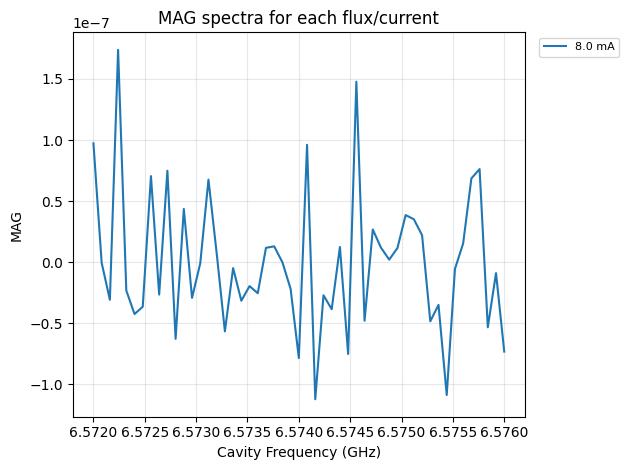

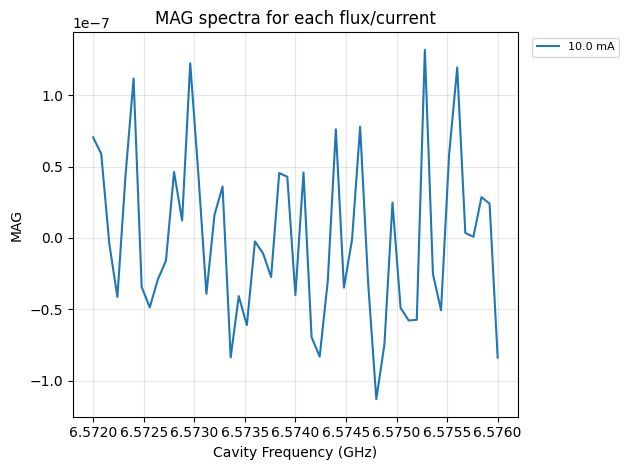

In [19]:
# ==========================================================
# 1D CUT: PLOT SPECTRUM FOR EACH FLUX/CURRENT
# ==========================================================

if load_npz_for_analysis:

    data = np.load(npz_path, allow_pickle=True)

    x_values = data["current"]          # A
    y_values = data["cav_if"] + lo      # Hz
    data_2d = data[plot_data]           # shape: (number of currents, number of freq points)

    # Convert frequency to GHz
    freq_GHz = y_values / 1e9

    # Convert current to mA
    current_mA = x_values * 1e3

    # ------------------------------------------------------
    # Plot all 1D cuts
    # ------------------------------------------------------
    plt.figure(figsize=(10, 6))

    for i, current in enumerate(current_mA):
        plt.plot(
            freq_GHz,
            data_2d[i],
            label=f"{current:.1f} mA"
        )

        plt.xlabel("Cavity Frequency (GHz)")
        plt.ylabel(plot_data)
        plt.title(f"{plot_data} spectra for each flux/current")
        plt.grid(alpha=0.3)
        plt.legend(
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            fontsize=8
        )
        plt.tight_layout()
        plt.show()

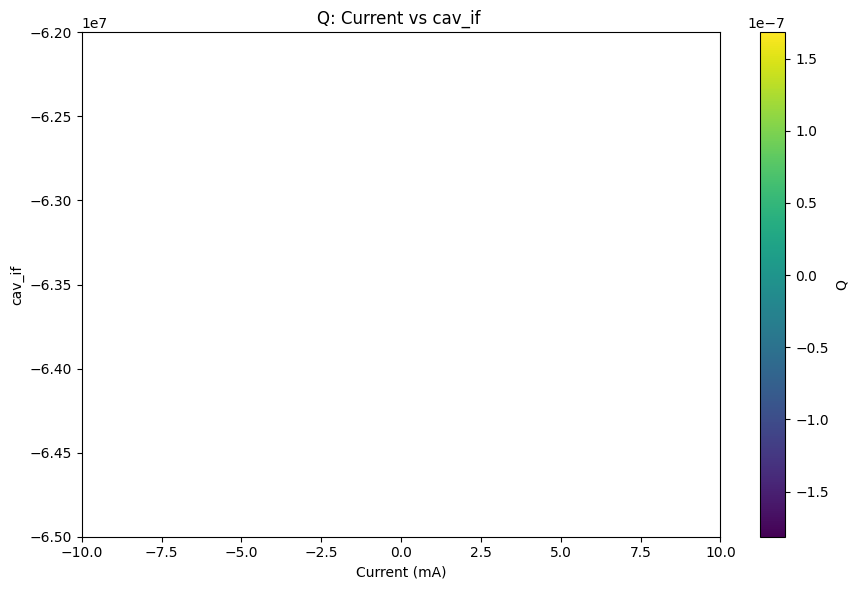

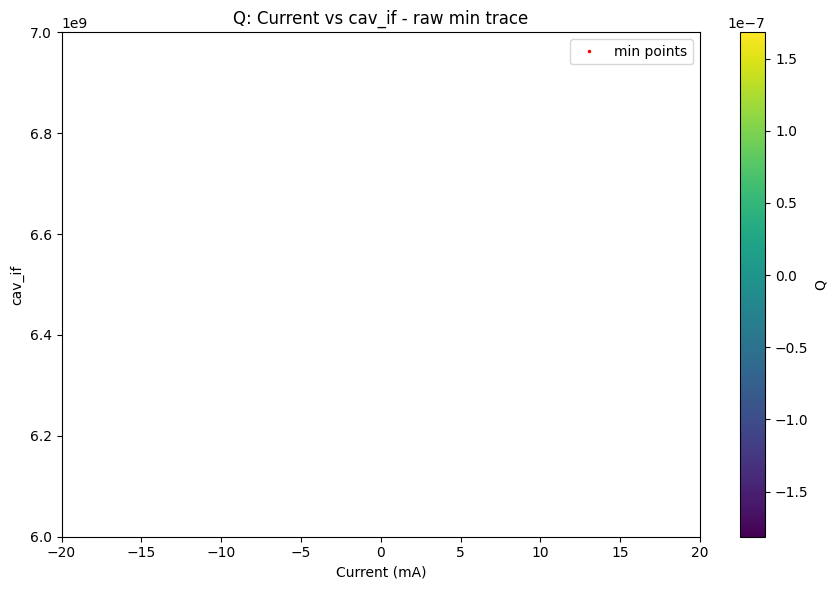

In [3]:
if load_npz_for_analysis:
    data = np.load(npz_path, allow_pickle=True)
    x_values = data["current"]
    y_values = data["cav_if"] if "cav_if" in data.keys() else data["y_values"]
    data_2d = data[plot_data]

    # Step 3: Raw 2D Mesh Plot
    base_mesh_plot(x_values, y_values, data_2d)

    plt.xlim(-10, 10)       # x-axis: -20 to +20 mA
    plt.ylim(-65e6, -62e6)  # y-axis: 6 to 7 GHz

    plt.show()

    # Step 4 & 5: Find Min/Max Trace & Plot Overlay
    idx = np.argmin(data_2d, axis=1) if find_mode == "min" else np.argmax(data_2d, axis=1)
    trace_y = y_values[idx]
    trace_val = data_2d[np.arange(data_2d.shape[0]), idx]

    base_mesh_plot(x_values, y_values, data_2d, f"- raw {find_mode} trace")

    plt.plot(
        x_values * 1e3 if plot_current_in_mA else x_values,
        trace_y,
        "r.",
        markersize=3,
        label=f"{find_mode} points"
    )

    plt.xlim(-20, 20)
    plt.ylim(6.0e9, 7.0e9)

    plt.legend()
    plt.show()

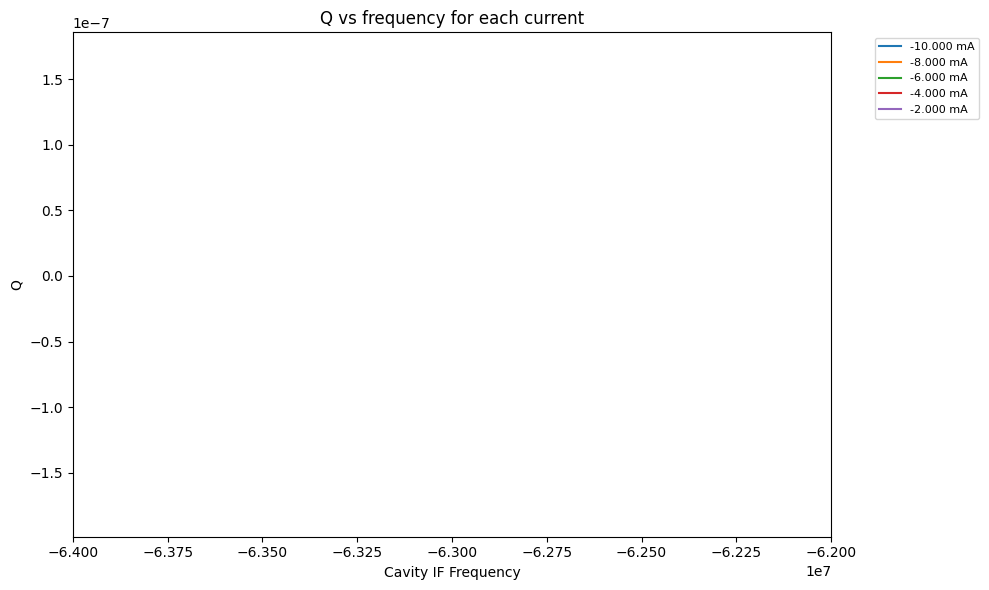

In [4]:
if load_npz_for_analysis:
    data = np.load(npz_path, allow_pickle=True)

    x_values = data["current"]
    y_values = data["cav_if"] if "cav_if" in data.keys() else data["y_values"]
    data_2d = data[plot_data]

    # Convert current to mA for labels
    currents_mA = x_values * 1e3

    # Plot 1D trace for each current
    plt.figure(figsize=(10, 6))

    for i, current in enumerate(currents_mA):
        plt.plot(
            y_values,
            data_2d[i, :],
            label=f"{current:.3f} mA"
        )

    plt.xlabel("Cavity IF Frequency")
    plt.ylabel(plot_data)
    plt.title(f"{plot_data} vs frequency for each current")

    # Optional limits
    plt.xlim(-64e6, -62e6)

    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=8
    )

    plt.tight_layout()
    plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

if load_npz_for_analysis:

    data = np.load(npz_path, allow_pickle=True)

    x_values = data["current"]
    y_values = data["cav_if"] if "cav_if" in data.keys() else data["y_values"]
    data_2d = data[plot_data]

    currents_mA = x_values * 1e3

    # ==========================================================
    # Gaussian function
    # ==========================================================
    def gaussian(x, amplitude, center, sigma, offset):
        return (
            offset
            + amplitude * np.exp(
                -(x - center)**2 / (2 * sigma**2)
            )
        )

    # ==========================================================
    # Store fitted resonance frequencies
    # ==========================================================
    fit_freq = []

    # ==========================================================
    # FIT EACH CURRENT SEPARATELY
    # ==========================================================
    for i, current in enumerate(currents_mA):

        x = y_values
        y = data_2d[i, :]

        # Fit range
        mask = (x >= -64e6) & (x <= -62e6)

        x_fit = x[mask]
        y_fit = y[mask]

        # Initial guesses
        center_guess = x_fit[np.argmin(y_fit)]
        offset_guess = np.max(y_fit)
        amplitude_guess = np.min(y_fit) - offset_guess
        sigma_guess = 0.2e6

        p0 = [
            amplitude_guess,
            center_guess,
            sigma_guess,
            offset_guess
        ]

        try:

            popt, pcov = curve_fit(
                gaussian,
                x_fit,
                y_fit,
                p0=p0,
                maxfev=10000
            )

            amplitude, center, sigma, offset = popt

            fit_freq.append(center)

            # ==================================================
            # Plot THIS CURRENT ONLY
            # ==================================================

            x_smooth = np.linspace(
                x_fit.min(),
                x_fit.max(),
                500
            )

            y_smooth = gaussian(
                x_smooth,
                *popt
            )

            plt.figure(figsize=(8, 5))

            # Measured data
            plt.plot(
                x_fit / 1e6,
                y_fit,
                "o",
                markersize=4,
                label="Measured"
            )

            # Gaussian fit
            plt.plot(
                x_smooth / 1e6,
                y_smooth,
                "-",
                linewidth=2,
                label="Gaussian fit"
            )

            # Fitted center
            plt.axvline(
                center / 1e6,
                linestyle="--",
                label=f"Center = {center/1e6:.6f} MHz"
            )

            plt.xlabel("Cavity IF frequency (MHz)")
            plt.ylabel(plot_data)

            plt.title(
                f"Gaussian fit — I = {current:.3f} mA"
            )

            plt.xlim(-64, -62)

            plt.grid(True)
            plt.legend()

            plt.tight_layout()
            plt.show()

        except RuntimeError:

            print(
                f"Fit failed at I = {current:.3f} mA"
            )

            fit_freq.append(np.nan)

    fit_freq = np.array(fit_freq)

    # ==========================================================
    # Resonance frequency vs current
    # ==========================================================

    plt.figure(figsize=(8, 5))

    plt.plot(
        currents_mA,
        fit_freq / 1e6,
        "o-",
        markersize=5
    )

    plt.xlabel("Current (mA)")
    plt.ylabel("Fitted resonance frequency (MHz)")

    plt.title("Resonance frequency vs current")

    plt.grid(True)

    plt.tight_layout()
    plt.show()

ValueError: attempt to get argmin of an empty sequence